# 02. Seller fixed-effects regression

## What we're testing and why

The RDD only looks at orders right around the promised date. Here we use **all** single-seller delivered orders and ask: *for the same seller, selling in the same category, in the same month, to the same state*, how much lower is the review when the order is late?

**Seller fixed effects** mean each seller gets their own baseline review level. So a seller who is simply bad at everything doesn't make lateness look worse than it is. We only compare a seller's late orders with that **same seller's** on-time orders.

The plan is pre-registered in `analysis_plan.md` (Test 2): two outcomes, a dose-response by days late, and one regional split.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf
from src.db import run_query

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
df = run_query("SELECT * FROM causal.fe_sample")

df["price"] = df["price"].astype(float)
df["freight"] = df["freight"].astype(float)
df["weight_g"] = df["weight_g"].astype(float)
df["distance_km"] = df["distance_km"].astype(float)
df["days_late"] = df["days_late"].astype(float)
df["purchase_month"] = df["purchase_month"].astype(str)

df["log_price"] = np.log(df["price"])
df["log_freight"] = np.log(1 + df["freight"])

print("Orders in FE sample:", len(df))
print("Sellers:", df["seller_id"].nunique())
df.head()

Orders in FE sample: 94563
Sellers: 2944


,order_id,seller_id,category,purchase_month,customer_state,customer_region,days_late,late,review_score,low_review,price,freight,distance_km,weight_g,n_items,promised_days,log_price,log_freight
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,cool_stuff,2017-09-01,RJ,Southeast,-9.0000,0,5,0,58.9000,13.2900,301.5047,650.0000,1,16,4.0758,2.6596
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,2017-04-01,SP,Southeast,-3.0000,0,4,0,239.9000,19.9300,585.5639,"30,000.0000",1,19,5.4802,3.0412
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,furniture_decor,2018-01-01,MG,Southeast,-14.0000,0,5,0,199.0000,17.8700,312.3435,"3,050.0000",1,22,5.2933,2.9376
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,perfumery,2018-08-01,SP,Southeast,-6.0000,0,4,0,12.9900,12.7900,293.1684,200.0000,1,12,2.5642,2.6239
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,garden_tools,2017-02-01,SP,Southeast,-16.0000,0,5,0,199.9000,18.1400,646.1635,"3,750.0000",1,41,5.2978,2.9518


In [3]:
controls = "log_price + log_freight + distance_km + weight_g + n_items + promised_days"
fixed_effects = "seller_id + category + purchase_month + customer_state"

fit_score = pf.feols("review_score ~ late + " + controls + " | " + fixed_effects, data=df, vcov={"CRV1": "seller_id"})
fit_low = pf.feols("low_review ~ late + " + controls + " | " + fixed_effects, data=df, vcov={"CRV1": "seller_id"})

pf.etable([fit_score, fit_low])

/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 545 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 545 singleton fixed effect(s) dropped from the model.
  warnings.warn(


GT(_tbl_data=   __index_level_0__ __index_level_1__                       0  \
0               coef              late  -1.947*** <br> (0.026)   
1               coef         log_price    -0.024* <br> (0.010)   
2               coef       log_freight  -0.055*** <br> (0.016)   
3               coef       distance_km  -0.000*** <br> (0.000)   
4               coef          weight_g      0.000 <br> (0.000)   
5               coef           n_items  -0.221*** <br> (0.014)   
6               coef     promised_days  -0.003*** <br> (0.001)   
7                 fe         category                        x   
8                 fe    customer_state                       x   
9                 fe   purchase_month                        x   
10                fe        seller_id                        x   
11             stats      Observations                  93,532   
12             stats                R²                   0.223   

                        1  
0   0.519*** <br> (0.007)  
1   0.009*** <br> (0.003)  
2     0.011* <br> (0.004)  
3      0.000 <br> (0.000)  
4     -0.000 <br> (0.000)  
5   0.059*** <br> (0.004)  
6    0.001** <br> (0.000)  
7                       x  
8                       x  
9                       x  
10                      x  
11                 93,532  
12                   0.22  , _body=<great_tables._gt_data.Body object at 0x14b164a10>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14b08a090>, _spanners=Spanners([SpannerInfo(spanner_id='review_score', spanner_level=1, spanner_label='review_score', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='low_review', spanner_level=1, spanner_label='low_review', spanner_units=None, spanner_pattern=None, vars=['1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x14b089a10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x14b1661d0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell: Coefficient   (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x14b166010>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', t

In [4]:
def late_row(fit, outcome, sample, variable="late"):
    t = fit.tidy()
    row = {}
    row["sample"] = sample
    row["outcome"] = outcome
    row["estimate"] = t.loc[variable, "Estimate"]
    row["se"] = t.loc[variable, "Std. Error"]
    row["ci_low"] = t.loc[variable, "2.5%"]
    row["ci_high"] = t.loc[variable, "97.5%"]
    row["p"] = t.loc[variable, "Pr(>|t|)"]
    row["n"] = fit._N
    return row


main_rows = []
main_rows.append(late_row(fit_score, "review_score", "all single-seller"))
main_rows.append(late_row(fit_low, "low_review", "all single-seller"))
main = pd.DataFrame(main_rows)

print("Mean review_score:", df["review_score"].mean())
print("Mean low_review:", df["low_review"].mean())
main

Mean review_score: 4.173059230354367
Mean low_review: 0.12348381502278905


,sample,outcome,estimate,se,ci_low,ci_high,p,n
0,all single-seller,review_score,-1.9473,0.0260,-1.9983,-1.8964,0.0000,93532
1,all single-seller,low_review,0.5186,0.0071,0.5046,0.5326,0.0000,93532


In [5]:
df["bin_le_m15"] = (df["days_late"] <= -15).astype(int)
df["bin_m14_m8"] = ((df["days_late"] >= -14) & (df["days_late"] <= -8)).astype(int)
df["bin_0"] = (df["days_late"] == 0).astype(int)
df["bin_1_3"] = ((df["days_late"] >= 1) & (df["days_late"] <= 3)).astype(int)
df["bin_4_7"] = ((df["days_late"] >= 4) & (df["days_late"] <= 7)).astype(int)
df["bin_8_14"] = ((df["days_late"] >= 8) & (df["days_late"] <= 14)).astype(int)
df["bin_ge_15"] = (df["days_late"] >= 15).astype(int)

bin_names = ["bin_le_m15", "bin_m14_m8", "bin_0", "bin_1_3", "bin_4_7", "bin_8_14", "bin_ge_15"]
bin_formula = " + ".join(bin_names)

fit_dose = pf.feols("review_score ~ " + bin_formula + " + " + controls + " | " + fixed_effects, data=df, vcov={"CRV1": "seller_id"})

dose_rows = []
for name in bin_names:
    row = late_row(fit_dose, "review_score", "dose_response", variable=name)
    row["bin"] = name
    dose_rows.append(row)

dose = pd.DataFrame(dose_rows)
dose

/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 545 singleton fixed effect(s) dropped from the model.
  warnings.warn(


,sample,outcome,estimate,se,ci_low,ci_high,p,n,bin
0,dose_response,review_score,0.2920,0.0131,0.2663,0.3178,0.0000,93532,bin_le_m15
1,dose_response,review_score,0.1606,0.0122,0.1367,0.1844,0.0000,93532,bin_m14_m8
2,dose_response,review_score,-0.1573,0.0373,-0.2304,-0.0842,0.0000,93532,bin_0
3,dose_response,review_score,-0.8329,0.0386,-0.9087,-0.7572,0.0000,93532,bin_1_3
4,dose_response,review_score,-2.0028,0.0406,-2.0825,-1.9231,0.0000,93532,bin_4_7
5,dose_response,review_score,-2.3979,0.0371,-2.4707,-2.3251,0.0000,93532,bin_8_14
6,dose_response,review_score,-2.3491,0.0397,-2.4271,-2.2712,0.0000,93532,bin_ge_15


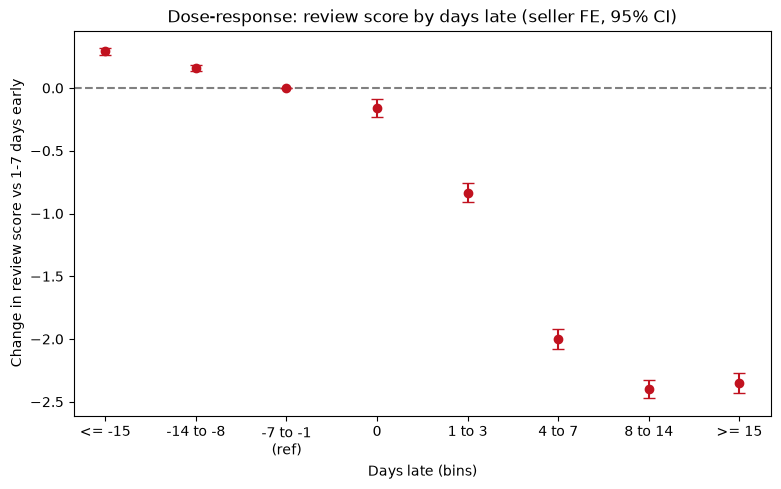

In [6]:
labels = ["<= -15", "-14 to -8", "-7 to -1\n(ref)", "0", "1 to 3", "4 to 7", "8 to 14", ">= 15"]
estimates = [dose["estimate"][0], dose["estimate"][1], 0, dose["estimate"][2], dose["estimate"][3], dose["estimate"][4], dose["estimate"][5], dose["estimate"][6]]
lows = [dose["ci_low"][0], dose["ci_low"][1], 0, dose["ci_low"][2], dose["ci_low"][3], dose["ci_low"][4], dose["ci_low"][5], dose["ci_low"][6]]
highs = [dose["ci_high"][0], dose["ci_high"][1], 0, dose["ci_high"][2], dose["ci_high"][3], dose["ci_high"][4], dose["ci_high"][5], dose["ci_high"][6]]

errors_low = []
errors_high = []
for i in range(len(estimates)):
    errors_low.append(estimates[i] - lows[i])
    errors_high.append(highs[i] - estimates[i])

plt.figure(figsize=(9, 5))
plt.errorbar(range(len(labels)), estimates, yerr=[errors_low, errors_high], fmt="o", color="#c1121f", capsize=4)
plt.axhline(0, color="grey", linestyle="--")
plt.xticks(range(len(labels)), labels)
plt.xlabel("Days late (bins)")
plt.ylabel("Change in review score vs 1-7 days early")
plt.title("Dose-response: review score by days late (seller FE, 95% CI)")
plt.savefig("../outputs/figures/fe_dose_response.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from scipy.stats import norm

north = df[df["customer_region"].isin(["North", "Northeast"])]
south = df[~df["customer_region"].isin(["North", "Northeast"])]
print("North + Northeast orders:", len(north))
print("South + Southeast + Centre-West orders:", len(south))

split_rows = []
for outcome in ["review_score", "low_review"]:
    fit_north = pf.feols(outcome + " ~ late + " + controls + " | " + fixed_effects, data=north, vcov={"CRV1": "seller_id"})
    fit_south = pf.feols(outcome + " ~ late + " + controls + " | " + fixed_effects, data=south, vcov={"CRV1": "seller_id"})

    row_north = late_row(fit_north, outcome, "North + Northeast")
    row_south = late_row(fit_south, outcome, "South + Southeast + Centre-West")

    z = (row_north["estimate"] - row_south["estimate"]) / np.sqrt(row_north["se"] ** 2 + row_south["se"] ** 2)
    p_diff = 2 * (1 - norm.cdf(abs(z)))
    row_north["z_diff"] = z
    row_north["p_diff"] = p_diff
    row_south["z_diff"] = z
    row_south["p_diff"] = p_diff

    split_rows.append(row_north)
    split_rows.append(row_south)

split = pd.DataFrame(split_rows)
split

North + Northeast orders: 10657
South + Southeast + Centre-West orders: 83906


/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 547 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 538 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 547 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/gandharv/Codebase/Olist/.venv/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 538 singleton fixed effect(s) dropped from the model.
  warnings.warn(


,sample,outcome,estimate,se,ci_low,ci_high,p,n,z_diff,p_diff
0,North + Northeast,review_score,-2.0200,0.0519,-2.1219,-1.9181,0.0000,10055,-1.5612,0.1185
1,South + Southeast + Centre-West,review_score,-1.9271,0.0290,-1.9841,-1.8702,0.0000,82937,-1.5612,0.1185
2,North + Northeast,low_review,0.5490,0.0161,0.5174,0.5806,0.0000,10055,2.1119,0.0347
3,South + Southeast + Centre-West,low_review,0.5110,0.0080,0.4954,0.5266,0.0000,82937,2.1119,0.0347


In [8]:
main.to_csv("../outputs/tables/test2_fe_results.csv", index=False)
dose.to_csv("../outputs/tables/test2_fe_dose_response.csv", index=False)
split.to_csv("../outputs/tables/test2_fe_heterogeneity.csv", index=False)

with open("../outputs/tables/test2_fe_results.md", "w") as f:
    f.write("# Test 2: Seller fixed effects\n\n")
    f.write(main.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n# Dose-response (outcome review_score, reference = 1-7 days early)\n\n")
    f.write(dose.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n# Heterogeneity (secondary)\n\n")
    f.write(split.to_markdown(index=False, floatfmt=".4f"))

## What this means for the business

**Main result (Test 2, pre-registered).** Comparing each seller's late orders with that **same seller's** on-time orders (also holding category, month and customer state fixed, plus price, freight, distance, weight, items and promise length):

- A late order gets **1.95 fewer stars** (95% CI −2.00 to −1.90, p < 0.001; N = 93,532, SEs clustered by seller).
- A late order is **51.9 percentage points more likely** to get a 1–2 star review (95% CI 50.5 to 53.3). The average low-review rate is about 12%.

**Dose-response.** Compared with arriving 1–7 days early: on the promised day −0.16; 1–3 days late −0.83; 4–7 days late −2.00; 8–14 days late −2.40; 15+ days late −2.35. Arriving very early (15+ days) adds +0.29. The harm grows with the delay and plateaus after about a week, which matches the RDD chart.

**Heterogeneity (secondary).** The star effect is similar in North/Northeast (−2.02) and South/Southeast/Centre-West (−1.93); the difference is not significant (p = 0.12). The low-review effect is slightly larger in North/Northeast (54.9 pp vs 51.1 pp, p = 0.035).

**For the business:** lateness is the single biggest driver of 1-star reviews that a seller controls. Getting an order from "4+ days late" back to "1–3 days late" recovers more than a full star.

**Limit:** fixed effects remove *stable* differences between sellers, categories, months and states, but not order-specific shocks. For example, a parcel damaged in transit may be both late and badly reviewed for the damage. So this is strong evidence, but not an experiment, and the true effect could be somewhat smaller.